<a href="https://colab.research.google.com/github/jerrinjoseph123/ML_AI_Learning/blob/main/Unsupervised_learning_Coding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from PIL import Image

import warnings

warnings.filterwarnings("ignore", category=UserWarning)

# Question 11

In [2]:
def k_means(X, k, max_iters=100, tol=1e-4):
    """
    K-means clustering algorithm.

    Parameters:
    X (ndarray): The dataset, a 2D array where each row is a point.
    k (int): Number of clusters.
    max_iters (int): Maximum number of iterations.
    tol (float): Tolerance for convergence.

    Returns:
    centroids (ndarray): Final centroids after convergence.
    labels (ndarray): Cluster assignment for each point.
    """
    # Step 1: Initialize centroids randomly from the data points
    np.random.seed(42)  # for reproducibility
    centroids = X[np.random.choice(X.shape[0], k, replace=False)]

    for _ in range(max_iters):
        # Step 2: Assign each point to the nearest centroid
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)

        # Step 3: Calculate new centroids
        new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])

        # Step 4: Check for convergence
        if np.linalg.norm(new_centroids - centroids) < tol:
            break
        centroids = new_centroids

    return centroids

X, _ = make_blobs(n_samples=300, centers=4, random_state=42)

# Running the k-means function
centroids = k_means(X, k=2)

centroids = np.round(centroids, 2)

print("Centroids:\n", centroids)

Centroids:
 [[-2.26  6.07]
 [-6.83 -6.83]]


# Question 12

In [3]:
def k_means_sklearn(X, k):
    """
    K-means clustering using scikit-learn's KMeans class.

    Parameters:
    X (ndarray): The dataset, a 2D array where each row is a point.
    k (int): Number of clusters.

    Returns:
    centroids (ndarray): Final centroids after convergence, rounded to 2 decimal places.
    labels (ndarray): Cluster assignment for each point.
    """
    # Initialize and fit the KMeans model
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)

    # Get centroids and labels
    centroids = np.round(kmeans.cluster_centers_, 2)  # Round centroids to 2 decimal places

    return centroids

X, _ = make_blobs(n_samples=300, centers=4, random_state=42)

# Running the k-means function using sklearn
centroids = k_means_sklearn(X, k=2)

print("Centroids:\n", centroids)

Centroids:
 [[-2.26  6.07]
 [-6.83 -6.83]]


## Look at bad initialization example

In [4]:
# look at a bad initialization example
X, y_true, true_centers = make_blobs(
    n_samples=300, centers=4, cluster_std=1.0, random_state=7, return_centers=True
)

Bad init  -> cluster sizes: [ 38  37 150  75]  inertia: 7034.9
Good init -> cluster sizes: [75 75 75 75]  inertia: 571.3


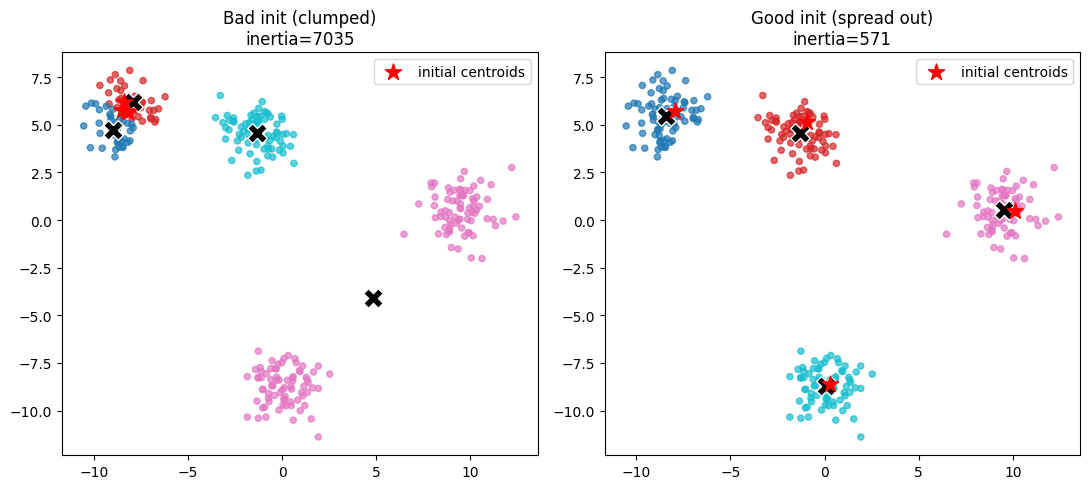

In [5]:
rng = np.random.RandomState(0)

# "Good" init: near the 4 true blob centers, spread across the space
good_init = true_centers + rng.normal(scale=0.3, size=true_centers.shape)

# "Bad" init: all 4 starting centroids crammed together near just ONE blob
bad_init = true_centers[0] + rng.normal(scale=0.4, size=(4, 2))

km_bad = KMeans(n_clusters=4, init=bad_init, n_init=1, random_state=0).fit(X)
km_good = KMeans(n_clusters=4, init=good_init, n_init=1, random_state=0).fit(X)

print("Bad init  -> cluster sizes:", np.bincount(km_bad.labels_), " inertia:", round(km_bad.inertia_, 1))
print("Good init -> cluster sizes:", np.bincount(km_good.labels_), " inertia:", round(km_good.inertia_, 1))

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].scatter(X[:, 0], X[:, 1], c=km_bad.labels_, cmap='tab10', s=20, alpha=0.7)
axes[0].scatter(km_bad.cluster_centers_[:, 0], km_bad.cluster_centers_[:, 1], c='black', marker='X', s=200, edgecolors='white')
axes[0].scatter(bad_init[:, 0], bad_init[:, 1], c='red', marker='*', s=150, label='initial centroids')
axes[0].set_title(f"Bad init (clumped)\ninertia={km_bad.inertia_:.0f}")
axes[0].legend()

axes[1].scatter(X[:, 0], X[:, 1], c=km_good.labels_, cmap='tab10', s=20, alpha=0.7)
axes[1].scatter(km_good.cluster_centers_[:, 0], km_good.cluster_centers_[:, 1], c='black', marker='X', s=200, edgecolors='white')
axes[1].scatter(good_init[:, 0], good_init[:, 1], c='red', marker='*', s=150, label='initial centroids')
axes[1].set_title(f"Good init (spread out)\ninertia={km_good.inertia_:.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

# Question 13

In [6]:
def k_means_with_silhouette(X, k):
    """
    K-means clustering using scikit-learn's KMeans class and calculating the Silhouette Score.

    Parameters:
    X (ndarray): The dataset, a 2D array where each row is a point.
    k (int): Number of clusters.

    Returns:
    centroids (ndarray): Final centroids after convergence, rounded to 2 decimal places.
    labels (ndarray): Cluster assignment for each point.
    silhouette (float): Silhouette Score of the clustering.
    """
    # Initialize and fit the KMeans model
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)

    # Get centroids and labels
    centroids = np.round(kmeans.cluster_centers_, 2)  # Round centroids to 2 decimal places
    labels = kmeans.labels_

    # Calculate Silhouette Score
    silhouette = silhouette_score(X, labels)

    return silhouette

X, _ = make_blobs(n_samples=300, centers=4, random_state=42)

# Running the k-means function with silhouette score
silhouette = k_means_with_silhouette(X, k=4)

print("Silhouette Score:", round(silhouette, 2))

Silhouette Score: 0.79


## Silhouette Score Examples

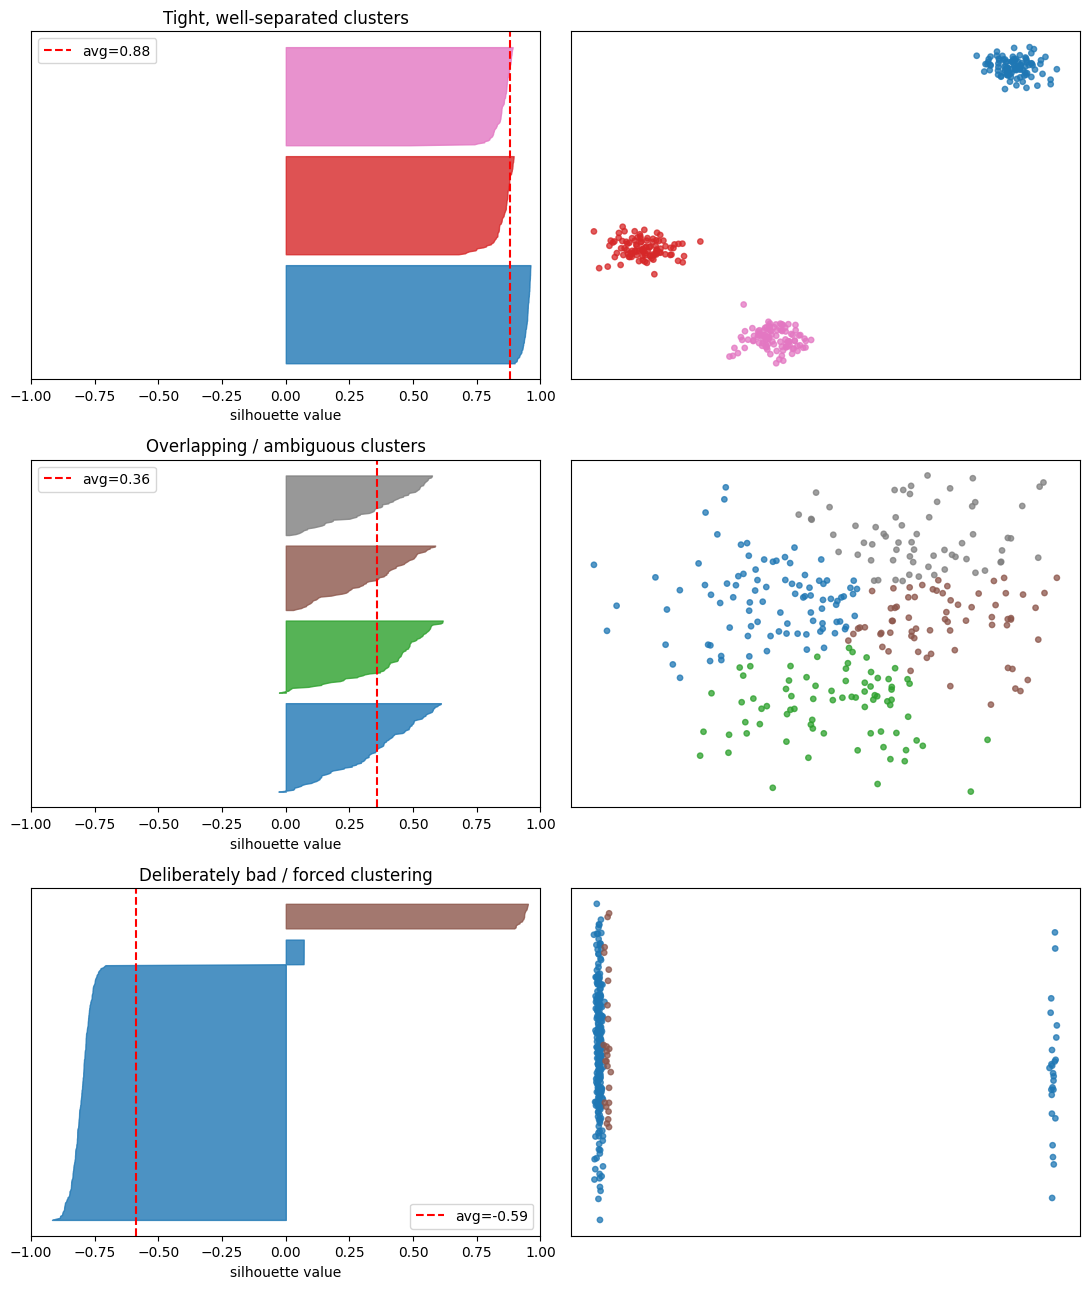

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

def silhouette_panel(ax_sil, ax_scatter, X, labels, title, n_clusters):
    """Classic silhouette-plot style: per-sample bars (left) + cluster scatter (right)."""
    sil_avg = silhouette_score(X, labels)
    sample_sil = silhouette_samples(X, labels)

    y_lower = 10
    for i in range(n_clusters):
        ith = np.sort(sample_sil[labels == i])
        y_upper = y_lower + len(ith)
        color = cm.tab10(i / max(n_clusters, 1))
        ax_sil.fill_betweenx(np.arange(y_lower, y_upper), 0, ith, facecolor=color, edgecolor=color, alpha=0.8)
        y_lower = y_upper + 10

    ax_sil.axvline(x=sil_avg, color="red", linestyle="--", label=f"avg={sil_avg:.2f}")
    ax_sil.set_xlim([-1, 1])
    ax_sil.set_yticks([])
    ax_sil.set_xlabel("silhouette value")
    ax_sil.legend(loc="lower right" if sil_avg < 0 else "upper left")
    ax_sil.set_title(title)

    colors = cm.tab10(labels.astype(float) / max(n_clusters, 1))
    ax_scatter.scatter(X[:, 0], X[:, 1], c=colors, s=15, alpha=0.75)
    ax_scatter.set_xticks([]); ax_scatter.set_yticks([])
    return sil_avg

fig, axes = plt.subplots(3, 2, figsize=(11, 13))

# scenario A: close to +1 — tight, well-separated clusters, correct k
XA, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.5, center_box=(-12, 12), random_state=1)
kmA = KMeans(n_clusters=3, n_init=10, random_state=1).fit(XA)
silhouette_panel(axes[0, 0], axes[0, 1], XA, kmA.labels_, "Tight, well-separated clusters", 3)

# scenario B: closer to 0 — overlapping/ambiguous clusters, correct k, real k-means
XB, _ = make_blobs(n_samples=300, centers=4, cluster_std=1.3, center_box=(-3, 3), random_state=11)
kmB = KMeans(n_clusters=4, n_init=10, random_state=11).fit(XB)
silhouette_panel(axes[1, 0], axes[1, 1], XB, kmB.labels_, "Overlapping / ambiguous clusters", 4)

# scenario C: close to -1 — deliberately bad, forced clustering
# Two clusters that are naturally CLOSE (should be separate colors) get FORCED into
# the same label alongside a far-away cluster, while a nearby cluster is split off alone.
nA, nC, nB, distB, cstd = 250, 25, 25, 100, 0.4
XcA, _ = make_blobs(n_samples=nA, centers=[[0, 0]], cluster_std=cstd, random_state=1)
XcC, _ = make_blobs(n_samples=nC, centers=[[2, 0]], cluster_std=cstd, random_state=2)   # near XcA
XcB, _ = make_blobs(n_samples=nB, centers=[[distB, 0]], cluster_std=cstd, random_state=3)  # far away
XC = np.vstack([XcA, XcC, XcB])
bad_labels = np.array([0] * nA + [1] * nC + [0] * nB)  # forces A + B together, splits off C alone
silhouette_panel(axes[2, 0], axes[2, 1], XC, bad_labels, "Deliberately bad / forced clustering", 2)

plt.tight_layout()
plt.show()

# Question 14

In [8]:
def perform_pca(X, n_components=2):
    """
    Perform Principal Component Analysis (PCA) on a dataset.

    Parameters:
    X (ndarray): The dataset, a 2D array where each row is a point and each column is a feature.
    n_components (int): Number of principal components to reduce the data to.

    Returns:
    X_pca (ndarray): Transformed data in the reduced PCA space.
    explained_variance_ratio (ndarray): Percentage of variance explained by each principal component.
    """
    # Initialize PCA with the specified number of components
    pca = PCA(n_components=n_components)

    # Fit and transform the data
    X_pca = pca.fit_transform(X)

    # Get the explained variance ratio
    explained_variance_ratio = pca.explained_variance_ratio_

    return explained_variance_ratio

X, _ = make_blobs(n_samples=300, centers=4, n_features=5, random_state=42)

# Performing PCA to reduce to 2 components
explained_variance_ratio = perform_pca(X, n_components=2)

explained_variance_ratio = np.round(explained_variance_ratio, 2)

print("Explained Variance Ratio:", explained_variance_ratio)

Explained Variance Ratio: [0.75 0.14]


Text(0, 0.5, 'Explained Variance Ratio')

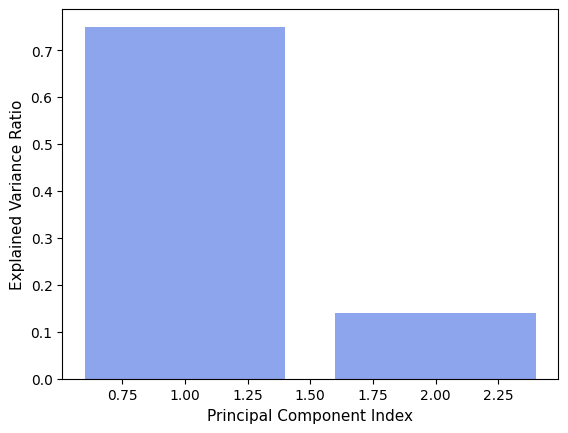

In [10]:
# Plot the individual variance as bars
num_comps = 2
bars = plt.bar(
    range(1, num_comps + 1),
    explained_variance_ratio,
    alpha=0.6,
    align='center',
    label='Individual Explained Variance',
    color='royalblue'
)

# Formatting and text elements
plt.xlabel('Principal Component Index', fontsize=11)

plt.ylabel('Explained Variance Ratio', fontsize=11)

## Principal Component Aside

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA

# first run downloads ~5MB (needs internet once, then it's cached locally)
faces = fetch_olivetti_faces(shuffle=True, random_state=42)
X, y = faces.data, faces.target   # X shape: (400, 4096) -- 64x64 pixels, flattened
image_shape = (64, 64)

print(f"Data shape: {X.shape}  ->  {X.shape[1]} features (pixels) per face")

# pixel intensities are already scaled 0-1, so no StandardScaler needed here
# (unlike Iris, every "feature" is a pixel on the same scale already)
pca_full = PCA()
pca_full.fit(X)

cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = np.argmax(cumulative_var >= 0.90) + 1
n_95 = np.argmax(cumulative_var >= 0.95) + 1
print(f"Components needed for 90% variance: {n_90}  (down from {X.shape[1]})")
print(f"Components needed for 95% variance: {n_95}  (down from {X.shape[1]})")

Data shape: (400, 4096)  ->  4096 features (pixels) per face
Components needed for 90% variance: 66  (down from 4096)
Components needed for 95% variance: 123  (down from 4096)


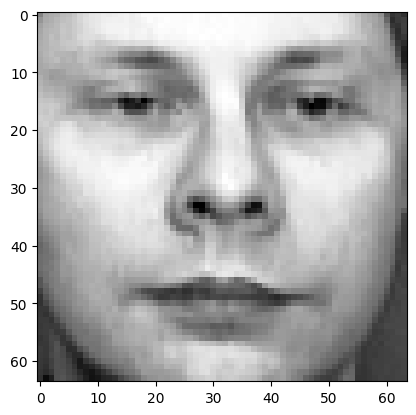

In [15]:
# plot an example image
img_idx = 2
plt.imshow(X[img_idx].reshape(image_shape), cmap='gray')

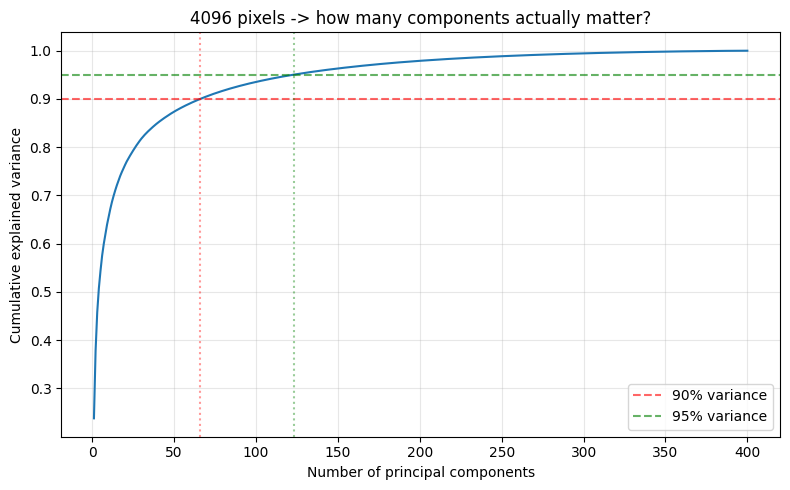

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_var) + 1), cumulative_var)
plt.axhline(y=0.90, color='r', linestyle='--', alpha=0.6, label='90% variance')
plt.axhline(y=0.95, color='g', linestyle='--', alpha=0.6, label='95% variance')
plt.axvline(x=n_90, color='r', linestyle=':', alpha=0.4)
plt.axvline(x=n_95, color='g', linestyle=':', alpha=0.4)
plt.xlabel('Number of principal components')
plt.ylabel('Cumulative explained variance')
plt.title('4096 pixels -> how many components actually matter?')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

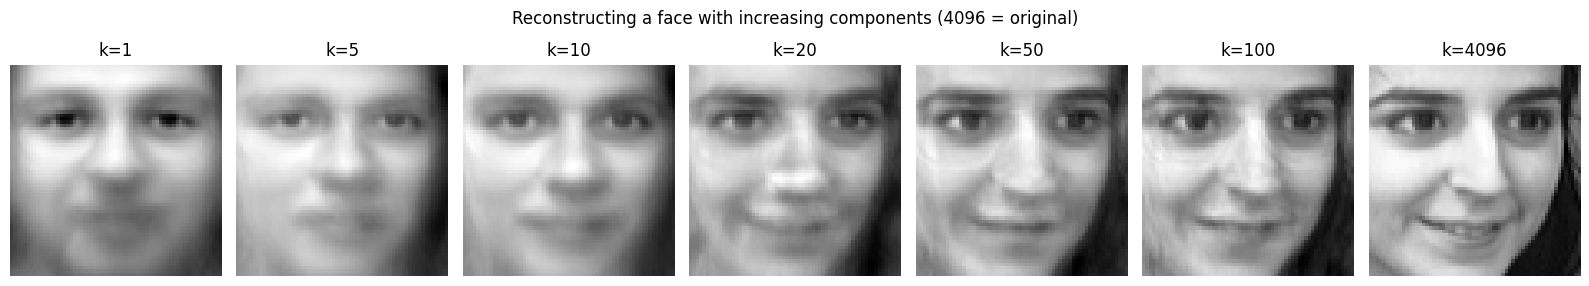

In [14]:
def reconstruct_with_k(X, k, sample_idx):
    pca = PCA(n_components=k)
    X_reduced = pca.fit_transform(X)
    return pca.inverse_transform(X_reduced)[sample_idx]

component_counts = [1, 5, 10, 20, 50, 100, 4096]  # 4096 = full, no loss
sample_idx = 4

fig, axes = plt.subplots(1, len(component_counts), figsize=(16, 3))
for ax, k in zip(axes, component_counts):
    if k == 4096:
        recon = X[sample_idx]
    else:
      recon = reconstruct_with_k(X, k, sample_idx)
    ax.imshow(recon.reshape(image_shape), cmap='gray')
    ax.set_title(f'k={k}')
    ax.axis('off')

fig.suptitle("Reconstructing a face with increasing components (4096 = original)")
plt.tight_layout()
plt.show()

# Question 15

- **Intuition behind finding the elbow point using the second derivative:**
  1. The first-order difference shows how fast WCSS decreases with increasing k.
  2. The second-order difference measures the slowdown in the rate of decrease.
  3. The elbow occurs where this slowdown is most significant, i.e., the second-order difference is minimal.

**Visualization:**
  - The elbow point appears as a noticeable "bend" in the WCSS plot.
  - Mathematically, this is where the second derivative indicates the steepest drop-off transitioning to a plateau.


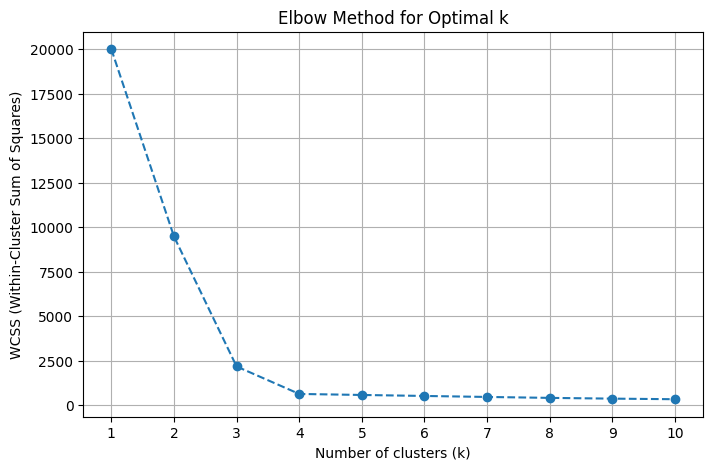


The optimal number of clusters is: 6


In [16]:
def optimal_k_elbow(data, max_k=10):
    """
    Determines the optimal number of clusters for k-means using the elbow method and plots the elbow graph.

    Parameters:
    - data: array-like, shape (n_samples, n_features)
      The data to cluster.
    - max_k: int, default=10
      The maximum number of clusters to consider.

    Returns:
    - optimal_k: int
      The optimal number of clusters based on the elbow method.
    """
    wcss = []

    # Compute WCSS for different values of k
    for k in range(1, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(data)
        wcss.append(kmeans.inertia_)

    # Plot the elbow plot
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, max_k + 1), wcss, marker='o', linestyle='--')
    plt.title('Elbow Method for Optimal k')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
    plt.xticks(range(1, max_k + 1))
    plt.grid(True)
    plt.show()

    # Find the "elbow" point using the second derivative
    wcss_diff = np.diff(wcss)
    wcss_diff2 = np.diff(wcss_diff)
    optimal_k = np.argmin(wcss_diff2) + 2  # +2 to account for the index offset

    return optimal_k

# Generate synthetic data for demonstration
data, _ = make_blobs(n_samples=300, centers=4, cluster_std=1.05, random_state=42)

# Find the optimal number of clusters and display the elbow plot
optimal_k = optimal_k_elbow(data)
print()
print(f"The optimal number of clusters is: {optimal_k}")

# Aside on DBSCAN

__What DBSCAN is__: DBSCAN (Density-Based Spatial Clustering of Applications with Noise) defines a cluster not by "points near a center" (like K-Means) but by "points packed densely together." A cluster is any region where points are tightly connected through their neighbors, however that region happens to be shaped — a blob, a crescent, a ring, a spiral, whatever. Points that don't belong to any dense region are labeled noise rather than forced into a cluster.

__How it "trains"__ (it's not learning in the ML sense — it's a direct geometric algorithm):
Every point gets classified based on two parameters, eps (a radius) and min_samples (a count):

__Core point__: has at least min_samples other points within distance eps of it.
Border point: isn't a core point itself, but falls within eps of one.
Noise point: neither — it's isolated.

Then DBSCAN just chains core points together: if two core points are within eps of each other, they're in the same cluster, and that chaining propagates transitively — so a cluster can snake along a curved, elongated, or irregular shape as long as there's an unbroken trail of dense points connecting it end to end. There's no centroid, no iterative optimization, no "loss function" to converge — it's a single deterministic pass (roughly, a connected-components search over a neighbor graph).

__Why it matters__:

It doesn't assume clusters are convex/spherical — the moons and circles example fixes exactly this K-Means blind spot.
It doesn't require you to specify k up front — the number of clusters emerges from the data and the density parameters, not a guess you have to justify beforehand.
It has a built-in concept of an outlier. K-Means is forced to assign every single point to some cluster, even ones that are clearly garbage; DBSCAN can just say "this doesn't belong anywhere," which is often exactly what you want for anomaly detection, sensor noise, or messy real-world data.

__Where it struggles__ — and the bridge to HDBSCAN:
DBSCAN uses one global eps for the entire dataset. That's a problem when clusters have different densities — an eps tuned for a tight cluster will treat a naturally sparser (but still real) cluster as noise, and an eps loose enough to catch the sparse cluster will merge nearby dense clusters together into one blob.

__HDBSCAN (Hierarchical DBSCAN)__ fixes exactly this by not committing to a single eps at all. Instead, it runs DBSCAN conceptually across every possible eps value at once, builds a hierarchy of how clusters merge and split as density thresholds change, and then extracts the most "stable" clusters from that hierarchy — the ones that persist across a wide range of density thresholds rather than being an artifact of one specific eps. That means it can find a tight cluster and a loose, sprawling cluster in the same dataset, without you having to pre-commit to one density scale for everything — while keeping DBSCAN's best ideas (arbitrary cluster shapes, no forced assignment, built-in noise detection).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score

configs = [
    ("Two moons", make_moons(n_samples=300, noise=0.07, random_state=42), 0.25),
    ("Concentric circles", make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42), 0.35),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

for row, (name, (X, y_true), eps) in enumerate(configs):
    Xs = StandardScaler().fit_transform(X)

    km = KMeans(n_clusters=2, n_init=10, random_state=0).fit(Xs)
    db = DBSCAN(eps=eps, min_samples=5).fit(Xs)

    ari_km = adjusted_rand_score(y_true, km.labels_)
    ari_db = adjusted_rand_score(y_true, db.labels_)

    axes[row, 0].scatter(Xs[:, 0], Xs[:, 1], c=y_true, cmap='coolwarm', s=15)
    axes[row, 0].set_title(f"{name}\nGround truth")

    axes[row, 1].scatter(Xs[:, 0], Xs[:, 1], c=km.labels_, cmap='coolwarm', s=15)
    axes[row, 1].scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
                          c='black', marker='X', s=150, edgecolors='white')
    axes[row, 1].set_title(f"K-Means (k=2)\nARI={ari_km:.2f}")

    axes[row, 2].scatter(Xs[:, 0], Xs[:, 1], c=db.labels_, cmap='coolwarm', s=15)
    axes[row, 2].set_title(f"DBSCAN (eps={eps})\nARI={ari_db:.2f}")

    for ax in axes[row]:
        ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

In [ ]:
X, y = make_moons(n_samples=300, noise=0.07, random_state=42)
X = StandardScaler().fit_transform(X)

eps_values = [0.1, 0.15, 0.25, 0.6]
fig, axes = plt.subplots(1, len(eps_values), figsize=(16, 4))
for ax, eps in zip(axes, eps_values):
    db = DBSCAN(eps=eps, min_samples=5).fit(X)
    labels = db.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    noise_mask = labels == -1
    ax.scatter(X[~noise_mask, 0], X[~noise_mask, 1], c=labels[~noise_mask], cmap='tab10', s=15)
    ax.scatter(X[noise_mask, 0], X[noise_mask, 1], c='lightgray', s=15, marker='x', label='noise')
    ax.set_title(f"eps={eps}\nclusters={n_clusters}, noise pts={n_noise}")
    ax.set_xticks([]); ax.set_yticks([])
    if n_noise > 0:
        ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

- eps=0.1 (too small): the neighborhood radius is too tight, so the algorithm can't "see" enough neighbors to connect points. The result: 18 fragmented micro-clusters and 182 points thrown away as noise (the gray ×'s).
- eps=0.15: better, but still badly fragmented (16 clusters, 49 noise points).
- eps=0.25 (just right): the two moons, perfectly.
- eps=0.6 (too large): the radius is now big enough to bridge the gap between the two moons entirely, everything collapses into a single cluster, exactly the same failure mode as picking the wrong k in K-Means, just for a different parameter.

# How does KMeans Test New Data?

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

X_train, y_train = make_blobs(n_samples=300, centers=4, cluster_std=1.0, random_state=7)

km = KMeans(n_clusters=4, n_init=10, random_state=7)
# centroids are learned ONLY from training data
km.fit(X_train)

centroids = km.cluster_centers_
print("Learned centroids:\n", centroids)

In [ ]:
new_points = np.array([
    [-2, 8],
    [7, 2],
    [0, -8],
    [-8, 5],
    [-4.88, 5.01],
])

# this is the prediction step
predicted = km.predict(new_points)

# reproduce what .predict() is doing internally, by hand:
for i, p in enumerate(new_points):
    # euclidean distance to all 4 centroids
    dists_to_each_centroid = np.linalg.norm(centroids - p, axis=1)
    # just pick the closest one
    manual_prediction = np.argmin(dists_to_each_centroid)
    print(f"point {p}:")
    print(f"  distance to each centroid = {np.round(dists_to_each_centroid, 2)}")
    print(f"  closest centroid index    = {manual_prediction}  (km.predict says {predicted[i]})")
    print()

In [ ]:
ex_pt = np.array([-2, 8])
a = np.linalg.norm(centroids - ex_pt, axis=1)
print(a)
np.argmin(a)

In [ ]:
x_min, x_max = X_train[:, 0].min() - 3, X_train[:, 0].max() + 3
y_min, y_max = X_train[:, 1].min() - 3, X_train[:, 1].max() + 3
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))

# predict the cluster for every point on a fine grid -- this reveals the full decision boundary
grid_preds = km.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 7))
ax.contourf(xx, yy, grid_preds, alpha=0.15, cmap='tab10')  # the "territory" of each centroid
ax.scatter(X_train[:, 0], X_train[:, 1], c=km.labels_, cmap='tab10', s=20, alpha=0.6, label='training data')
ax.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', s=250,
           edgecolors='white', linewidths=1.5, label='learned centroids', zorder=5)

for p, pred in zip(new_points, predicted):
    ax.scatter(*p, c='none', edgecolors='red', marker='o', s=200, linewidths=2.5, zorder=6)
    ax.plot([p[0], centroids[pred, 0]], [p[1], centroids[pred, 1]], 'r--', linewidth=1.5, zorder=4)

ax.scatter([], [], c='none', edgecolors='red', marker='o', s=200, linewidths=2.5, label='new unseen points')
ax.legend(loc='upper right', fontsize=11)
ax.set_title("Predicting on new data: nearest centroid wins")
plt.tight_layout()
plt.show()